# COMP0142

# Assignment: Polynomial Regression, Regularization and Logistic Regression

## Introduction

In this assignment you will implement Polynomial Regression, Regularization and Logistic Regression using the library Scikit-learn. 

In Part A of the assignment we will focus on Polynomial regression with and without regularization. First, we will load the train and test dataset and we will fit a simple polynomial of order 2 to see how to combine the classes `PolynomialFeatures` and `LinearRegression`. Then we will fit polynomials of different orders to the training data and we will compute the Mean Squared Error (MSE) of the train and test datasets. We will plot the MSE values to find out which polynomial order fits the data better. Afterwards we will select a specific polynomial degree and we will observe and analyse the impact of regularisation.

In Part B of the assignment we will apply a LASSO Regression model to the `mtcars.csv` dataset. We will observe how increasing the hyperparameter pushes the weight coefficients to zero more aggressively than in the case of Ridge Regression. 

In Part C of this assignment, we are going to implement Logistic Regression. First, we are going to examine how data scaling affects the performance of the classifier: We will produce a classification report and plot a confusion matrix. We are then going to use cross validation to more reliably compare the performance of the models.

We are going to work with a synthetic dataset and then the following two datasets:
- The 'mtcars' dataset
- The 'Gene expression cancer RNA-Seq' dataset 

## Guidelines

- The structure of the code is given to you and you will need to fill in the parts corresponding to each question. 
- You will have to submit the completed notebook in the Jupyter notebook format: `.ipynb`.
- Do not modify/erase other parts of the code if you have not been given specific instructions to do so.
- When you are asked to insert code, do so between the areas which begin:
  
  `##########################################################`
  
  `# TO_DO`
  
  `# [your code here]`
   
   And which end:
   
  `# /TO_DO
   ##########################################################`


- When you are asked to comment on the results you should give clear and comprehensible explanations. Write the comments in a 'Code Cell' with a sign `#` at the beginning of each row, and in the areas which begin:

  `# [INSERT YOUR ANSWER HERE]`

## Imports

Please do not change the cell below, you will see a number of imports. All these packages are relevant for the assignment and it is important that you get used to them. You can find more information about them in the respective documentations. The most relevant for this assignment is Scikit-learn:

https://scikit-learn.org/stable/

In [1]:
# PLEASE DO NOT CHANGE THIS CELL

import pandas as pd
import numpy as np

# Standard python libraries for data and visualisation
import matplotlib.pyplot as plt

import pylab
%matplotlib inline
import seaborn as sns

# SciKit Learn a python ML Library
# Import models
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import LogisticRegression

# Import error metric
from sklearn.metrics import mean_squared_error

# Import data munging tools
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn import preprocessing

# Import error metric
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load files
import pickle

# Import library for handling warnings
import warnings

# Part A: Polynomial Regression [80 marks]

In the lectures, we introduced a 1-dimensional input dataset, that gave rise to the following set of $n$ output,input pairs:

$$ \mathcal{S} =\{ (x^{(i)}, y^{(i)}) \}^{n}_{i=1}$$

We want to fit a polynomial of degree $k$ to form the following prediction function:

$$ f_k(x) =  w_0 + w_1 x + w_2 x^2 + \ldots + w_k x^k $$

We can transform this problem to a linear regression problem by transforming the input data:

$$\mathbf{X} = \left[\begin{array}{cccc}
1 & x^{(1)} & (x^{(1)})^2 & \dots & (x^{(1)})^k \\
1 & x^{(2)} & (x^{(2)})^2 & \dots & (x^{(2)})^k \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x^{(n)} & (x^{(n)})^2 & \dots & (x^{(n)})^k \\
\end{array}\right], 
\mathbf{y} = \left[\begin{array}{c}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{array}\right], 
\mathbf{w} = \left[\begin{array}{c}
w_0 \\
w_1 \\
w_2 \\
\vdots \\
w_k
\end{array}\right]
$$

`PolynomialFeatures` transforms the 1-dimensional array $[x^{(1)},...,x^{(n)}]^T$ into the matrix $\mathbf{X}$. Now, we can use the `LinearRegression` class to fit the data as we did during the regression class.

The loss function that the model is minimising is:

\begin{equation}
\mathsf{L}(\mathcal{E},\mathcal{S}, \mathbf{w}) = \Vert\mathbf{y}- \mathbf{Xw}\Vert^2_2
\end{equation}

We begin by loading the data and plotting it:

In [2]:
# PLEASE DO NOT CHANGE THIS CELL
# Load Data

with open('data_pol_fit.pkl', 'rb') as handle:
    data = pickle.load(handle)

X = data['X']
y = data['y']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

X_grid = np.linspace(-2,2,num=100)[:,np.newaxis]

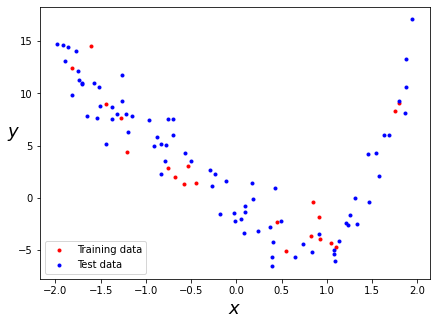

In [3]:
# PLEASE DO NOT CHANGE THIS CELL

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_train, y_train, c='r', marker='.', label="Training data")
ax.scatter(x_test, y_test, c='b', marker='.', label="Test data")
ax.legend()
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.show()

We fit a polynomial of order 2 to the training dataset and we plot the results:

In [4]:
# PLEASE DO NOT CHANGE THIS CELL

poly_features = PolynomialFeatures(degree=2)

x_train_poly = poly_features.fit_transform(x_train)
X_grid_poly = poly_features.fit_transform(X_grid)

lin_reg = LinearRegression()
lin_reg.fit(x_train_poly, y_train)

y_grid_pred = lin_reg.predict(X_grid_poly)

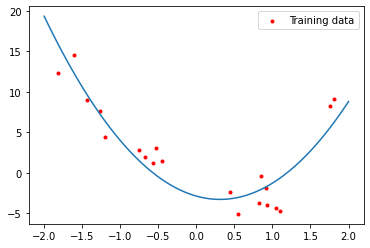

In [5]:
# PLEASE DO NOT CHANGE THIS CELL

fig, ax = plt.subplots()
ax.scatter(x_train, y_train, c='r', marker='.', label="Training data")
ax.legend()
plt.plot(X_grid, y_grid_pred)
plt.show()

### _Question 1 [20 marks]_

Using the same approach fit 0-th to 10-th order polynomials to the training data. 
For each polynomial order you should:

- Create a Polynomial features instance (call it poly_features) and transform your training and test datasets
- Create a Linear regression model (call it lin_reg) and fit it with the train set
- Compute the predictions of the model for the train and test set
- Compute the Mean Square Error for the train and test set (think about using the `mean_squared_error` function for Scikit-learn) and append the values to mses_train and mses_test



In [6]:
########################################################
# PLEASE DO NOT MODIFY THIS CODE SEGMENT

y_preds = []
mses_train = []
mses_test = []
max_degree = 10
for degree in range(max_degree+1):
#
########################################################

########################################################
# TO_DO

    poly_features = PolynomialFeatures(degree=degree)

    x_train_poly = poly_features.fit_transform(x_train)
    x_test_poly = poly_features.transform(x_test)
 
    lin_reg = LinearRegression()
    lin_reg.fit(x_train_poly, y_train)

    y_train_pred = lin_reg.predict(x_train_poly)
    y_test_pred = lin_reg.predict(x_test_poly)

    mses_train.append(mean_squared_error(y_train, y_train_pred))
    mses_test.append(mean_squared_error(y_test, y_test_pred))

    
    
# /TO_DO
########################################################

########################################################
# PLEASE DO NOT MODIFY THIS CODE SEGMENT

    X_grid_poly = poly_features.fit_transform(X_grid)
    y_grid_pred = lin_reg.predict(X_grid_poly)
    y_preds.append(y_grid_pred)
#
########################################################

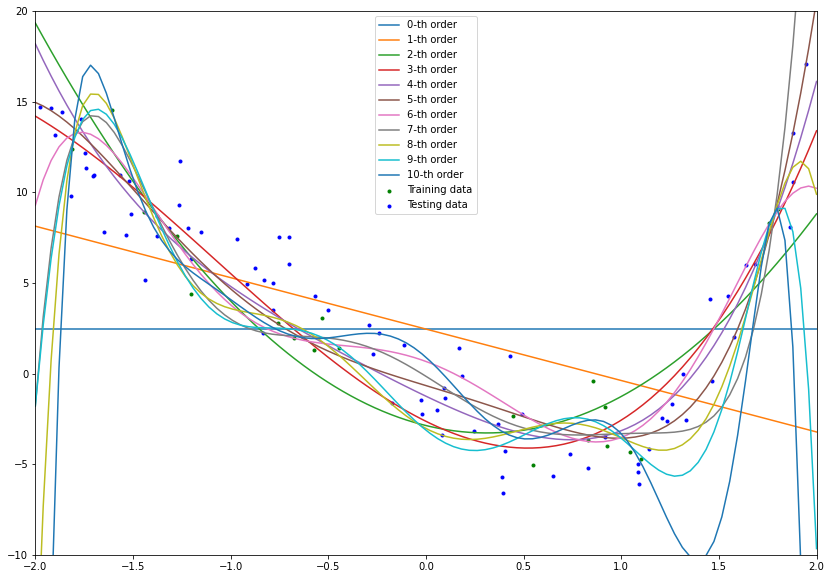

In [7]:
# PLEASE DO NOT CHANGE THIS CELL

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(x_train, y_train, c='g', marker='.', label="Training data")
ax.scatter(x_test, y_test, c='b', marker='.', label="Testing data")

for degree in range(0,max_degree+1):
    ax.plot(X_grid, y_preds[degree], label="{}-th order".format(degree))

ax.axis([-2, 2, -10, 20])
ax.legend()
plt.show()

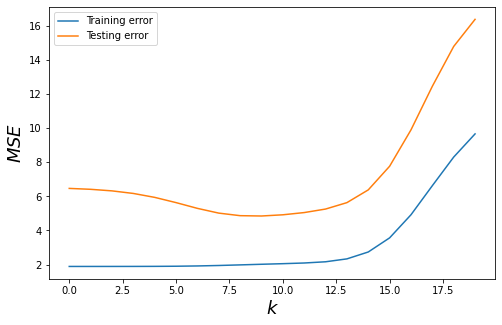

In [36]:
# PLEASE DO NOT CHANGE THIS CELL

fig, ax = plt.subplots(figsize = (8,5))
ax.plot(mses_train, label="Training error")
ax.plot(mses_test, label="Testing error")
plt.xlabel("$k$", fontsize=18)
plt.ylabel("$MSE$",fontsize=18)
ax.legend()
#ax.axis([0, 10, 0, 40])
plt.show()

### _Question 2 [20 marks]_
What is your interpretation of the mean squared error plot? What is happening between $k = 0$ and $k = 10$? Which polynomial order you think fits better the data?

In [8]:

# From the mean squared error plot, we can see that the training error decreases
# as k increases. This is because higher-order polynomials are more flexible and
# can fit the training data more closely. In contrast, the testing error decreases
# at first, and appears to be lowest at k = 4, and then increases for larger values
# of k.

# For small values of k, such as k = 0 or k = 1, both the training and testing errors are high,
# with the testing MSE being approximately 40 at k = 0. This indicates underfitting, 
# because low-order polynomials are too simple to capture the non-linear relationship in the data, 
# leading to high bias.

# As k increases from 0 to around 4, the model improves because it becomes
# flexible enough to capture the main structure of the data. This is the region
# where the trade-off between bias and variance appears to be best.

# For values of k larger than about 4, the training error continues to decrease,
# but the testing error increases. This is a sign of overfitting: the model is
# fitting the training data too closely and is no longer generalising well to
# unseen data. At k=10, the model exhibits extreme variance, while the training MSE is low, 
# the testing MSE rises to over 100. This again suggests overfitting, so the highest-order
# polynomial gives a particularly poor out-of-sample fit.
# Considering both the MSE plot and the fitted curves, the polynomial order k=4 appears to fit the data best,
# since it captures the main trend without the instability seen at higher orders. It gives
# the lowest testing error while keeping the training error low, so it provides
# the best bias-variance trade-off between fitting the training data and generalising to new
# data.


### Regularization

In this section, we will analyse the impact of regularization in the model fitting. 

We will implement Polynomial Ridge Regression so the loss function is:

\begin{equation}
\mathsf{L}(\mathcal{E},\mathcal{S},\mathbf{w}) = \Vert\mathbf{y}- \mathbf{Xw}\Vert^2_2 + \lambda \Vert\mathbf{w}\Vert^2_2
\end{equation}

where $\lambda$ is the regularization parameter.

To observer the impact of regularization we will specify that the polynomial order is 6 (we could have chosen any another order) and we will fit the polynomial regression with different $\lambda$ values.

We will use the `Ridge` Scikit-learn class. You can find information and examples of how to use it in:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge

### _Question 3 [20 marks]_

Fit a 6-th order polynomial to the training data.

For each $\lambda$-value you should:

- Create a Ridge regression model `Ridge` (call it ridge_reg) with the lambda_value and fit it to the train set
- Compute the predictions of the model for the train and test set
- Compute the Mean Square Error for the train and test set (think about using the `mean_squared_error` function for Scikit-learn) and append the values to mses_train and mses_test


In [9]:
# PLEASE DO NOT CHANGE THIS CELL

lambda_list = np.logspace(-3.0, 2.0, num=20)
print(lambda_list)

[1.00000000e-03 1.83298071e-03 3.35981829e-03 6.15848211e-03
 1.12883789e-02 2.06913808e-02 3.79269019e-02 6.95192796e-02
 1.27427499e-01 2.33572147e-01 4.28133240e-01 7.84759970e-01
 1.43844989e+00 2.63665090e+00 4.83293024e+00 8.85866790e+00
 1.62377674e+01 2.97635144e+01 5.45559478e+01 1.00000000e+02]


In [10]:
########################################################
# PLEASE DO NOT MODIFY THIS CODE SEGMENT

y_preds = []
mses_train = []
mses_test = []

poly_features = PolynomialFeatures(degree=6)
x_train_poly = poly_features.fit_transform(x_train)
x_test_poly = poly_features.transform(x_test)
X_grid_poly = poly_features.transform(X_grid)

for lambda_value in lambda_list:
#
#########################################################

#########################################################
# TO_DO

    ridge_reg = Ridge(alpha=lambda_value)
    ridge_reg.fit(x_train_poly, y_train)

    y_train_pred = ridge_reg.predict(x_train_poly)
    y_test_pred = ridge_reg.predict(x_test_poly)

    mses_train.append(mean_squared_error(y_train, y_train_pred))
    mses_test.append(mean_squared_error(y_test, y_test_pred))
    
# /TO_DO
#########################################################

#########################################################
# PLEASE DO NOT MODIFY THIS CODE SEGMENT

    y_grid_pred = ridge_reg.predict(X_grid_poly)
    y_preds.append(y_grid_pred)
#
#########################################################

We plot the MSE of the train and test set for each lamba_value:

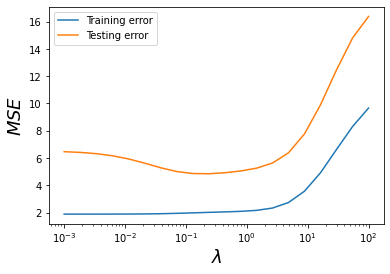

In [11]:
# PLEASE DO NOT CHANGE THIS CELL

fig, ax = plt.subplots()
ax.plot(lambda_list,mses_train, label="Training error")
ax.plot(lambda_list,mses_test, label="Testing error")
ax.legend()
plt.xlabel("$\lambda$", fontsize=18)
plt.ylabel("$MSE$",fontsize=18)
ax.set_xscale('log')
plt.show()

In [12]:
# PLEASE DO NOT CHANGE THIS CELL

lambda_argmin = np.argmin(mses_test)
lambda_opt  = lambda_list[lambda_argmin]
print(lambda_opt)

0.23357214690901212


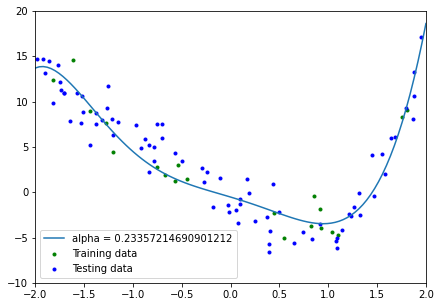

In [13]:
# PLEASE DO NOT CHANGE THIS CELL

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_train, y_train, c='g', marker='.', label="Training data")
ax.scatter(x_test, y_test, c='b', marker='.', label="Testing data")

ax.plot(X_grid, y_preds[lambda_argmin], label="alpha = {}".format(lambda_opt)) 

ax.axis([-2, 2, -10, 20])
ax.legend()
plt.show()

### _Question 4 [20 marks]_
What is your interpretation of the mean squared error plot? What happens when $\lambda$ increases? Is the regularization working?

In [14]:

# From the mean squared error plot, we can see that the testing error decreases
# at first as lambda increases from very small values, reaches its minimum at
# around lambda = 0.23, and then increases again for larger values of lambda.
# In contrast, the training error is smallest for very small lambda and then
# increases steadily as lambda becomes larger.

# This reflects the bias-variance trade-off. When lambda is very small, the
# regularization is weak, so the model remains highly flexible and is more likely
# to overfit the training data. As lambda increases, the regularization penalty
# becomes stronger, shrinking the polynomial coefficients towards zero. This makes
# the fitted curve smoother and less flexible, which reduces overfitting and
# improves generalization. This is why the testing error falls at first.

# However, once lambda becomes too large, the regularization is too strong and the
# model becomes overly restricted. At that point, it can no longer capture the
# underlying structure of the data properly, so both the training and testing
# errors increase. This indicates underfitting.

# Therefore, the regularization is working. It improves the model up to an
# optimal value of lambda, approximately 0.23, where the testing MSE is
# lowest. Beyond this point, increasing lambda further harms performance because
# the model becomes too simple. The fitted curve at the optimal lambda is smooth
# and captures the main trend of the data without the excessive oscillations seen
# in the unregularized high-degree polynomial model.


# Part B: LASSO Regression [20 marks]

In this part of the Assignment, we will analyse the impact of $l1$-regularization in linear regression. We will apply LASSO Regression, so now the loss function is:

\begin{equation}
\tilde L(\mathcal{E},\mathcal{S},w) = ||\mathbf{y}- \mathbf{Xw}||^2_2 + \lambda ||\mathbf{w}||_1
\end{equation}

where $\lambda$ is the regularization parameter.

We will observe how this method shrinks some weights more aggressively to zero by using a range of different $\lambda$ values.

We will use the `Lasso` Scikit-learn class. You can find information and examples of how to use it in:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso

First, we load the `mtcars.csv` file that contains data about car characteristics. 
It contains 11 car attributes and we will use Miles per gallon (mpg) as our target value.

1. 	cyl:	Number of cylinders
2. 	disp:   Displacement (cu.in.)
3. 	hp:	    Gross horsepower
4. 	drat:	Rear axle ratio
5. 	wt: 	Weight (1000 lbs)
6. 	qsec: 	1/4 mile time
7. 	vs: 	Engine (0 = V-shaped, 1 = straight)
8. 	am: 	Transmission (0 = automatic, 1 = manual)
9. 	gear: 	Number of forward gears
10. carb: 	Number of carburetors 
11. mpg: 	Miles/(US) gallon

In [15]:
# PLEASE DO NOT CHANGE THIS CELL

data = pd.read_csv('mtcars.csv', index_col = 0)
data.head()

,brand,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg
0,Mazda RX4,6,160.0,110,3.90,2.620,16.46,0,1,4,4,21.0
1,Mazda RX4 Wag,6,160.0,110,3.90,2.875,17.02,0,1,4,4,21.0
2,Datsun 710,4,108.0,93,3.85,2.320,18.61,1,1,4,1,22.8
3,Hornet 4 Drive,6,258.0,110,3.08,3.215,19.44,1,0,3,1,21.4
4,Hornet Sportabout,8,360.0,175,3.15,3.440,17.02,0,0,3,2,18.7


In [16]:
# PLEASE DO NOT CHANGE THIS CELL

X = data.iloc[:,1:-1]
y = data.iloc[:,-1]
X_colLabels = X.columns[:]

X = preprocessing.scale(X)
y = preprocessing.scale(y)

### _Question 5 [10 marks]_

Now, do the following:

- Apply a Ridge and a LASSO regression to the dataset `X` with target values `y` for each lambda value and append the weights/coefficients of each model in the lists `weights_ridge` and `weights_lasso`(check the `.coef_` method for the `Ridge` and `Lasso` class).

In [17]:
########################################################
# PLEASE DO NOT MODIFY THIS CODE SEGMENT

lambda_list = np.logspace(-5.0, 5, num=100)

weights_ridge = []
weights_lasso = []

for lambda_value in lambda_list:
    
#
#######################################################

    #######################################################
    # TO_DO
    
    # Lasso(...) or Ridge(...) is the same as defining reg_type = Lasso/Ridge and then calling reg_type(...)
    # since reg_type is just the class name
    
    ridge_model = Ridge(alpha=lambda_value)
    ridge_model.fit(X, y)
    weights_ridge.append(ridge_model.coef_)

    lasso_model = Lasso(alpha=lambda_value, max_iter=10000)
    lasso_model.fit(X, y)
    weights_lasso.append(lasso_model.coef_)

    # /TO_DO
    ##########################################################

Here we can see how the weights are pushed to zero more aggresively for the LASSO regression in comparison to the Ridge regression:

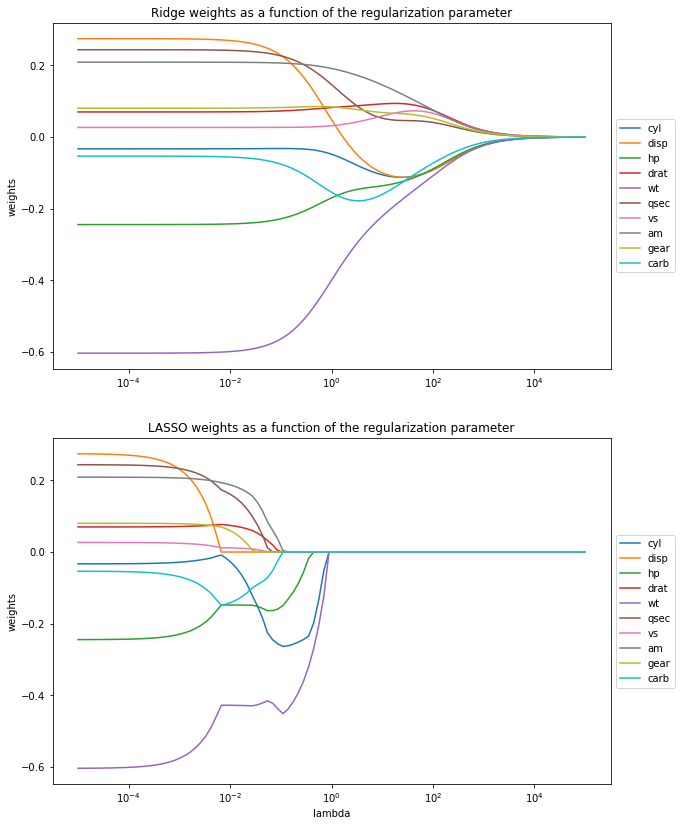

In [18]:
# PLEASE DO NOT CHANGE THIS CELL

fig = plt.figure(figsize = (10,14))
ax = fig.add_subplot(211)
ax.plot(lambda_list, weights_ridge)
ax.set_xscale('log')
ax.legend(labels = X_colLabels, loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('weights')
plt.title('Ridge weights as a function of the regularization parameter')

ax = fig.add_subplot(212)
ax.plot(lambda_list, weights_lasso)
ax.set_xscale('log')
ax.legend(labels = X_colLabels, loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('lambda')
plt.ylabel('weights')
plt.title('LASSO weights as a function of the regularization parameter')
plt.show()

### _Question 6 [10 marks]_

Finally, do the following:

- Compute in which order the attributes weights go to zero when we increase the lambda value using `weights_lasso` and `X_colLabels`.

In [19]:
########################################################
# PLEASE DO NOT MODIFY THIS CODE SEGMENT

weights_ordering = []
    
#
#######################################################

#######################################################
# TO_DO

# Use a small tolerance. LASSO coefficients may not be exactly zero due to numerical precision
tol = 1e-5

for j in range(len(weights_lasso[0])):
    for i, w in enumerate([row[j] for row in weights_lasso]):
        if abs(w) < tol:
            weights_ordering.append((X_colLabels[j], lambda_list[i]))
            break
    else:
        weights_ordering.append((X_colLabels[j], lambda_list[-1]))

weights_ordering = [name for name, _ in sorted(weights_ordering, key=lambda x: x[1])]

# /TO_DO
##########################################################

########################################################
# PLEASE DO NOT MODIFY THIS CODE SEGMENT

print(weights_ordering)


##################

['disp', 'gear', 'qsec', 'vs', 'drat', 'carb', 'am', 'hp', 'cyl', 'wt']


# Part C: Logistic Regression [50 marks]

## Gene expression dataset
This dataset contains gene expression data from patients diagnosed with one of tumor types: BRCA, KIRC, COAD, LUAD and PRAD. Each feature corresponds to a different gene. 

Dataset location: https://archive.ics.uci.edu/ml/datasets/gene+expression+cancer+RNA-Seq

Number of instances: 801

Number of features: 20531   

All of these parameters are real-valued continuous. To reduce computation time, we are going to work with the first 200 features.

## Load dataset
Please save the `data.csv` and `labels.csv` files included in the assignment zip file, which contain this data, and change the paths below to the paths leading to the location of your downloaded files. You may want to use os.chdir to change directory. 

In [20]:
# PLEASE CHANGE THE FILE PATHS AS NEEDED

file_path_data = "data.csv"
file_path_labels = "labels.csv"

In [21]:
#PLEASE DO NOT CHANGE THIS CELL

# read the file with pandas.read_csv
X = pd.read_csv(file_path_data, usecols=[*range(1, 201)])
y = pd.read_csv(file_path_labels, usecols=[1]).values.ravel()

label_list = ["BRCA", "KIRC", "COAD", "LUAD", "PRAD"]

In [22]:
#PLEASE DO NOT CHANGE THIS CELL

# Functions to use
# Decision boundary plotting 
def plot_predictions(X, y, clf):
    h = .02  # step size in the mesh
 
    # create a mesh to plot in
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    plt.figure(figsize=(8,6))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot also the training points
    pylab.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=plt.cm.coolwarm)
    plt.xlabel(list(X.head(0))[0])
    plt.ylabel(list(X.head(0))[1])
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(np.arange(min(X.iloc[:, 0]), max(X.iloc[:, 0])+1, 1.0))
    plt.yticks(np.arange(min(X.iloc[:, 1]), max(X.iloc[:, 1])+1, 1.0))
    plt.title(clf)

    plt.show
    
# confusion matrix plotting
def plot_conf_matrix(conf_matrix):
    plt.figure(figsize=(5,5))
    sns.heatmap(conf_matrix, annot=True, cmap="YlGnBu" ,fmt='g')    
    plt.ylabel('Actual label');
    plt.xlabel('Predicted label');

## Data analysis and pre-processing 
Below, we will generate histograms of the first 12 'Gene expression cancer RNA-Seq' dataset features.

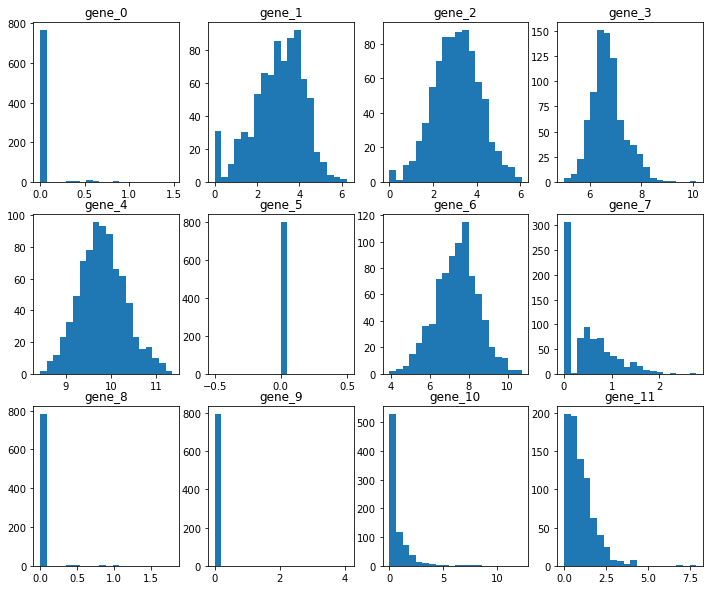

In [23]:
#PLEASE DO NOT CHANGE THIS CELL

figs, axs = plt.subplots(3, 4, figsize=(12, 10))
axs = axs.ravel()

for counter in range(12):
    col = X.columns[counter]
    axs[counter].hist(X[col], bins=20)
    axs[counter].set_title(col)

Regularisation makes the classifier dependent on the scale of the features. 

We are going to scale the features and compare the performance of Logistic Regression on unscaled and scaled dataset. 

### _Question 7 [10 marks]_ 

### _a) [3 marks]_ 
- Use `StandardScaler()` to scale the data. Save the result to a new variable (do not overwrite X).

In [24]:
#######################################################
# TO_DO

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original X shape:", X.shape)
print("Scaled X shape:", X_scaled.shape)

#/TO_DO
#######################################################

Original X shape: (801, 200)
Scaled X shape: (801, 200)


### _b) [3 marks]_
-  Explain how the `StandardScaler()` function changes the data, (in particular its mean and variance)? (**Hint:** You can re-run the code from the section **Data analysis and pre-processing** in order to visualise scaled values.)

In [25]:

# The StandardScaler() function standardises each feature individually, for a given feature with n data points, it 
# calculates the mean by summing all the values and then dividing by n, and the standard deviation by summing all the 
# squared differences from the mean of the feature and then dividing by n, and taking a square root. It then maps
# all of the data points from the feature to new ones by subtracting the mean of the feature from each point and then 
# dividing by the standard deviation. This gives each feature a mean of 0 and variance of 1 up to floating point precision, 
# with small rounding errors in numerical computation, but they are effectively negligible. This process is called a z-score 
# normalisation. The shape of the distribution doesnt change, only the scale and location are adjusted, this can be 
# visualised by adapting the histogram code from the Data analysis and pre-processing section to run on the scaled data,
# and indeed the transformation preserves the shapes of the histograms but centres them at 0 with standard deviation of 1.


### _c) [4 marks]_
- `LogisticRegression()` uses $\ell_2$ regularisation as default. Briefly explain the effect of such a regulariser. Furthermore, briefly explain why data scaling might be a useful pre-processing step before the application of such a regulariser.

In [26]:

# The default l2 regulariser adds a penalty term to the loss function that grows with the size of the models weights. 
# The term is the sum of the squared weights. This is so that the optimisation process is forced to keep the weights 
# relatively small, instead of letting them get arbitrarily large. This prevents overfitting as the model becomes less 
# sensitive to individual features and is less likely to fit noise in the training data which in turn improves generalisation
# to new data. It also shrinks weights that are not useful for prediction towards 0, reducing their influence. In cases where
# the data are perfectly separable, logistic regression without regularisation would try to push the weights to infinity to
# achieve perfect separation. Adding the l2 penalty term makes the optimisation problem strictly convex ensuring a finite 
# unique solution exists.

# L2 regularisation penalises the magnitude of the weights directly. If features are on very different scales, features 
# with much smaller numerical ranges will need larger weights to have the same impact on the prediction. These larger weights 
# are then penalised harder by the regulariser, even if the feature is important. By scaling the features to mean 0 and 
# variance 1 [like with StandardScaler()], the regularisation penalty becomes applied fairly across the features, and the 
# magnitude of a weight more accurately reflects the importance of its corresponding feature leading to more reliable model 
# performance and interpretable weights.


### Classifier performance analysis

A Confusion Matrix is a table used for the evaluation of classification models. The x axis represents predicted labels while the y axis represents actual labels. Each cell indicates the sum of instances assigned to a particular combination of these labels. Diagonal values represents correctly classified instances.  

### _Question 8 [20 marks]_

### _a) [5 marks]_ 
- Create training and testing datasets for the unscaled and scaled data (set `random_state=42` and `train_size=0.7` when making your split).

In [27]:
lg = LogisticRegression(solver = "lbfgs", multi_class = "multinomial", max_iter = 5000)
lg_scaled = LogisticRegression(solver = "lbfgs", multi_class = "multinomial", max_iter = 5000)

#######################################################
# TO_DO

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Unscaled - train shape:", X_train.shape, "test shape:", X_test.shape)
print("Scaled - train shape:", X_train_scaled.shape, "test shape:", X_test_scaled.shape)
print("y train shape:", y_train.shape, "y test shape:", y_test.shape)

#/TO_DO
#######################################################

Unscaled - train shape: (560, 200) test shape: (241, 200)
Scaled - train shape: (560, 200) test shape: (241, 200)
y train shape: (560,) y test shape: (241,)


### _b) [5 marks]_ 
- Fit `LogisticRegression()` to the unscaled and scaled data.

In [28]:
with warnings.catch_warnings():
    
    ########################################################
    # TO_DO

    # NB: you may wish to comment out this filter
    warnings.simplefilter("ignore")
        
    lg.fit(X_train, y_train)
    lg_scaled.fit(X_train_scaled, y_train)
    print("Unscaled model - number of features:", lg.coef_.shape)
    print("Scaled model - number of features:", lg_scaled.coef_.shape)
    
    #/TO_DO
    #######################################################

Unscaled model - number of features: (5, 200)
Scaled model - number of features: (5, 200)


### _c) [5 marks]_ 
- Plot confusion matrices for the scaled and unscaled data using Scikit-learn `confusion_matrix()` and the `plot_conf_matrix()` function defined for you at the beginning of the notebook.

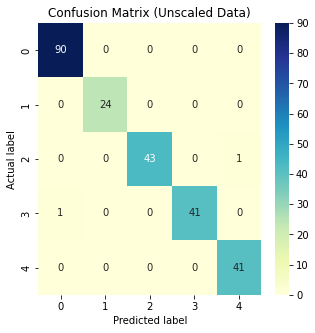

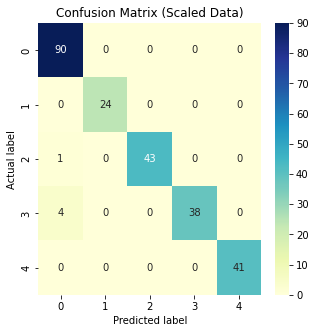

In [29]:
#######################################################
# TO_DO

y_pred = lg.predict(X_test)
y_pred_scaled = lg_scaled.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

plot_conf_matrix(cm)
plt.title("Confusion Matrix (Unscaled Data)")
plt.show()

plot_conf_matrix(cm_scaled)
plt.title("Confusion Matrix (Scaled Data)")
plt.show()

#/TO_DO
#######################################################

### _d) [5 marks]_ 
- Print a classification report using scikit-learn `classification_report()` function. You can use `target_names = label_list` to include labels.

In [30]:
with warnings.catch_warnings():
    
    ########################################################
    # TO_DO
    
    warnings.simplefilter("ignore")
    
    y_pred = lg.predict(X_test)
    y_pred_scaled = lg_scaled.predict(X_test_scaled)

    print("Classification Report - Unscaled Data")
    print(classification_report(y_test, y_pred, target_names=label_list))

    print("\nClassification Report - Scaled Data")
    print(classification_report(y_test, y_pred_scaled, target_names=label_list))
    
    #/TO_DO
    #######################################################

Classification Report - Unscaled Data
              precision    recall  f1-score   support

        BRCA       0.99      1.00      0.99        90
        KIRC       1.00      1.00      1.00        24
        COAD       1.00      0.98      0.99        44
        LUAD       1.00      0.98      0.99        42
        PRAD       0.98      1.00      0.99        41

    accuracy                           0.99       241
   macro avg       0.99      0.99      0.99       241
weighted avg       0.99      0.99      0.99       241


Classification Report - Scaled Data
              precision    recall  f1-score   support

        BRCA       0.95      1.00      0.97        90
        KIRC       1.00      1.00      1.00        24
        COAD       1.00      0.98      0.99        44
        LUAD       1.00      0.90      0.95        42
        PRAD       1.00      1.00      1.00        41

    accuracy                           0.98       241
   macro avg       0.99      0.98      0.98       241
we

### Cross validation
In Scikit-learn, `StratifiedKFold()` splits the data into $k$ different folds.  
`cross_val_score()` then uses these folds to run the classifier multiple times and collect multiple accuracy scores.   

### _Question 9 [20 marks]_

### _a) [5 marks]_ 
- Split data using `StratifiedKFold()`. Set `n_splits = 10`, `shuffle = True`, and `random_state=42`.

In [31]:
with warnings.catch_warnings():
    
    ########################################################
    # TO_DO

    # NB: you may wish to comment out this filter
    warnings.simplefilter("ignore")
            
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    #/TO_DO
    ########################################################

### _b) [5 marks]_ 
- Calculate cross validation scores using `cross_val_score()`. Call the variables storing these scores `lg_scores` and `lg_scaled_scores` (for consistency with plotting done for you in the subsequent section). (**Hint:** `cv` is equal to the output of `StratifiedKFold()`.)

In [32]:
with warnings.catch_warnings():
    
    ########################################################
    # TO_DO

    # NB: you may wish to comment out this filter
    warnings.simplefilter("ignore")
    
    from sklearn.pipeline import make_pipeline
    
    # pipeline performs standardisation within each cross-validation fold
    pipeline = make_pipeline(
        StandardScaler(), LogisticRegression(solver="lbfgs", multi_class="multinomial", max_iter=5000))

    lg_scores = cross_val_score(lg, X, y, cv=skf, scoring='accuracy')
    lg_scaled_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')
    
    
    #/TO_DO
    ########################################################

### _c) [5 marks]_ 
- Calculate and print the mean of the scores.

In [33]:
with warnings.catch_warnings():
    
    ########################################################
    # TO_DO

    # NB: you may wish to comment out this filter
    warnings.simplefilter("ignore")
        
    print("Mean accuracy (unscaled):", round(lg_scores.mean(), 4))
    print("Mean accuracy (scaled):", round(lg_scaled_scores.mean(), 4))
    
    #/TO_DO
    ########################################################

Mean accuracy (unscaled): 0.995
Mean accuracy (scaled): 0.9938


### _d) [5 marks]_ 
- Unlike vanilla `KFold()`, `StratifiedKFold()` aims to preserve the proportion of examples belonging to each class in each split. Does `StratifiedKFold()` make each data split balanced if the whole dataset is not balanced?

In [34]:

# No, StratifiedKFold() does not make each data split balanced if the whole dataset is not balanced. Instead, it preserves 
# the original class proportions in each fold. Therefore if the full dataset has an imbalanced distribution, (e.g. one class
# is overrepresented), each fold will reflect that that same imbalance. The aim is to ensure each fold is representative of
# the overall dataset, not to create artificially balanced splits, which is important for reliable cross validation on 
# imbalanced classification problems. In order to balance the folds, we would need oversampling or undersampling which
# StratifiedKFold() does not do.


We can visualise the scores using a box plot. It highlights the lower and upper quartiles, and "whiskers" showing the extent of the scores.  

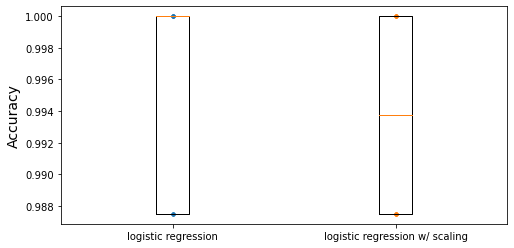

In [35]:
#PLEASE DO NOT CHANGE THIS CELL

plt.figure(figsize=(8, 4))
plt.plot([1]*10, lg_scores, ".")
plt.plot([2]*10, lg_scaled_scores, ".")
plt.boxplot([lg_scores, lg_scaled_scores], labels=("logistic regression","logistic regression w/ scaling"))
plt.ylabel("Accuracy", fontsize=14)
plt.show()